# Trail Popularity Prediction - Final Analysis
## Complete Preprocessing + Feature Optimization + XAI/SHAP
Single streamlined notebook using original preprocessing pipeline

In [1]:
# CELL 1: IMPORTS & SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
import warnings
import os
from math import radians, sin, cos, sqrt, atan2

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All imports successful")

✓ All imports successful


/Users/drapcat/4380env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CELL 2: HAVERSINE FUNCTION FOR METRO FEATURES
def haversine(lat1, lon1, lat2, lon2):
    """Calculate haversine distance between two points in km."""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

print("✓ Haversine function loaded")

✓ Haversine function loaded


In [3]:
# CELL 3: COMPLETE PREPROCESSING PIPELINE
print("="*80)
print("STEP 1: LOAD & PREPROCESS DATA (Using Original Pipeline)")
print("="*80)

# Load data
df = pd.read_csv('./Data/preprocessed_trails.csv')
print(f"\nDataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# STEP 1: Prepare features
y = df['popularity'].copy()
X = df.drop(columns=['popularity']).copy()

print(f"Target (y): {y.shape[0]:,} samples")
print(f"Features (X): {X.shape}")
print(f"\nTarget statistics:")
print(f"  Mean: {y.mean():.2f}, Median: {y.median():.2f}, Std: {y.std():.2f}")

# STEP 2: Encode categorical features
print("\n" + "-"*80)
print("ENCODING CATEGORICAL FEATURES")
print("-"*80)

# routeType: Ordinal encoding
if 'routeType' in X.columns:
    route_map = {'P': 1, 'O': 2, 'L': 3}
    X['routeType_encoded'] = X['routeType'].map(route_map)
    X = X.drop(columns=['routeType'])
    print("✓ Ordinal encoded routeType (P=1, O=2, L=3)")

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=['bool']).columns
for col in bool_cols:
    X[col] = X[col].astype(int)

if len(bool_cols) > 0:
    print(f"✓ Converted {len(bool_cols)} boolean columns to int (0/1)")

# One-hot encode categorical columns
categorical_cols = ['cityName', 'stateName', 'areaType']

for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown')
        encoded = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X, encoded], axis=1)
        X = X.drop(columns=[col])
        print(f"✓ One-hot encoded {col} ({len(encoded.columns)} columns)")

print(f"\nFeature shape after encoding: {X.shape}")

# STEP 3: Create metro features (if file exists, else skip)
print("\n" + "-"*80)
print("CREATING METRO FEATURES")
print("-"*80)

metro_path = './Data/usmetros.csv'
if os.path.exists(metro_path) and 'latitude' in X.columns and 'longitude' in X.columns:
    try:
        metros = pd.read_csv(metro_path)
        metros.rename(columns={'lat': 'metro_lat', 'lng': 'metro_lng'}, inplace=True)
        
        distances = []
        nearest_pop = []
        pop_sum_3 = []
        
        metro_coords = metros[['metro_lat', 'metro_lng']].values
        metro_pops = metros['population'].values
        
        print(f"Calculating distances to {len(metros)} metros...")
        
        for idx, row in X.iterrows():
            if idx % 500 == 0:
                print(f"  Progress: {idx} / {len(X)}")
            
            lat, lon = row['latitude'], row['longitude']
            
            dists = np.array([
                haversine(lat, lon, mlat, mlon)
                for (mlat, mlon) in metro_coords
            ])
            
            sorted_idx = np.argsort(dists)
            distances.append(dists[sorted_idx[0]])
            nearest_pop.append(metro_pops[sorted_idx[0]])
            pop_sum_3.append(metro_pops[sorted_idx[:3]].sum())
        
        X['dist_to_nearest_metro_km'] = distances
        X['nearest_metro_population'] = nearest_pop
        X['sum_population_3_nearest_metros'] = pop_sum_3
        
        print("✓ Created 3 metro-based features")
    except Exception as e:
        print(f"⚠ Could not create metro features: {e}")
else:
    print("⚠ Metro file not found or lat/lon missing - skipping metro features")

# STEP 4: Remove location and categorical columns
print("\n" + "-"*80)
print("REMOVING LOCATION & CATEGORICAL COLUMNS")
print("-"*80)

cols_to_remove = ['trail_id', 'latitude', 'longitude', 'trailType']
cols_to_drop = [col for col in cols_to_remove if col in X.columns]

if cols_to_drop:
    X = X.drop(columns=cols_to_drop)
    print(f"✓ Dropped {len(cols_to_drop)} location columns: {cols_to_drop}")

# STEP 5: Handle missing values
print("\n" + "-"*80)
print("HANDLING MISSING VALUES")
print("-"*80)

missing_counts = X.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0]

if len(cols_with_missing) > 0:
    print(f"Found {len(cols_with_missing)} columns with missing values:")
    for col, count in cols_with_missing.items():
        pct = (count / len(X)) * 100
        print(f"  - {col}: {count} ({pct:.2f}%)")
        if X[col].dtype in ['int64', 'float64']:
            median = X[col].median()
            X[col].fillna(median, inplace=True)
else:
    print("✓ No missing values found")

print(f"\nFinal preprocessed dataset: {X.shape}")
print(f"Feature dtypes check:")
print(X.dtypes.value_counts())

STEP 1: LOAD & PREPROCESS DATA (Using Original Pipeline)

Dataset loaded: 4,565 rows, 93 columns
Target (y): 4,565 samples
Features (X): (4565, 92)

Target statistics:
  Mean: 77.31, Median: 83.95, Std: 21.71

--------------------------------------------------------------------------------
ENCODING CATEGORICAL FEATURES
--------------------------------------------------------------------------------
✓ Ordinal encoded routeType (P=1, O=2, L=3)
✓ Converted 7 boolean columns to int (0/1)
✓ One-hot encoded cityName (415 columns)
✓ One-hot encoded stateName (7 columns)
✓ One-hot encoded areaType (14 columns)

Feature shape after encoding: (4565, 525)

--------------------------------------------------------------------------------
CREATING METRO FEATURES
--------------------------------------------------------------------------------
Calculating distances to 387 metros...
  Progress: 0 / 4565
  Progress: 500 / 4565
  Progress: 1000 / 4565
  Progress: 1500 / 4565
  Progress: 2000 / 4565
  Pro

In [4]:
# CELL 4: TRAIN/TEST SPLIT
print("\n" + "="*80)
print("STEP 2: TRAIN/TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✓ Training set: {len(X_train):,} samples, {X_train.shape[1]} features")
print(f"✓ Testing set: {len(X_test):,} samples, {X_test.shape[1]} features")
print(f"\nAll features are numeric: {X_train.select_dtypes(include=[np.number]).shape[1] == X_train.shape[1]}")


STEP 2: TRAIN/TEST SPLIT

✓ Training set: 3,652 samples, 525 features
✓ Testing set: 913 samples, 525 features

All features are numeric: False


In [20]:
# CELL 5: FEATURE OPTIMIZATION - STRATEGY 1: Importance
print("\n" + "="*80)
print("STEP 3: FEATURE OPTIMIZATION - STRATEGY 1: Feature Importance")
print("="*80)

# Train baseline
baseline = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
baseline.fit(X_train, y_train)

# Get importances
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': baseline.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<40} {row['importance']:.6f}")

# Test different feature counts
n_features_list = [15, 30, 50, 100, 125, 150, 175, 200, 300, 400, 522]
importance_results = []

print("\nTesting different feature counts...")
for n_features in n_features_list:
    if n_features > len(X_train.columns):
        continue
    
    selected_features = feature_importance.head(n_features)['feature'].tolist()
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]
    
    model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, 
                        random_state=42, verbosity=0, n_jobs=-1)
    model.fit(X_train_sel, y_train)
    
    y_pred = model.predict(X_test_sel)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    importance_results.append({
        'Strategy': 'Importance',
        'N_Features': n_features,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    print(f"  n_features={n_features:3d}: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

importance_df = pd.DataFrame(importance_results)
print(f"\n✓ Strategy 1 complete")


STEP 3: FEATURE OPTIMIZATION - STRATEGY 1: Feature Importance

Top 10 features:
  isClosed                                 0.254607
  numFeaturedPhotos_pct                    0.113287
  collections_trending                     0.070858
  avgRating                                0.049923
  collections_with_photos_pct              0.029895
  stateName_Colorado                       0.016520
  numRecordings_pct                        0.015897
  numPOIs                                  0.015881
  activities_walking                       0.014658
  areaType_W                               0.011383

Testing different feature counts...
  n_features= 15: R²=0.8120, RMSE=9.4249, MAE=6.4922
  n_features= 30: R²=0.8416, RMSE=8.6510, MAE=5.9923
  n_features= 50: R²=0.8449, RMSE=8.5598, MAE=6.0127
  n_features=100: R²=0.8477, RMSE=8.4843, MAE=5.9195
  n_features=125: R²=0.8525, RMSE=8.3487, MAE=5.8311
  n_features=150: R²=0.8556, RMSE=8.2593, MAE=5.8261
  n_features=175: R²=0.8520, RMSE=8.3629, MA

In [6]:
# CELL 6: FEATURE OPTIMIZATION - STRATEGY 2: Correlation
print("\n" + "="*80)
print("FEATURE OPTIMIZATION - STRATEGY 2: Correlation-Based")
print("="*80)

correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print(f"\nTop 10 correlated features:")
for feat, corr in correlations.head(10).items():
    print(f"  {feat:<40} {corr:.6f}")

# Test thresholds
correlation_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
correlation_results = []

print("\nTesting different correlation thresholds...")
for threshold in correlation_thresholds:
    selected_features = correlations[correlations >= threshold].index.tolist()
    
    if len(selected_features) < 5:
        continue
    
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]
    
    model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                        random_state=42, verbosity=0, n_jobs=-1)
    model.fit(X_train_sel, y_train)
    
    y_pred = model.predict(X_test_sel)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    correlation_results.append({
        'Strategy': 'Correlation',
        'N_Features': len(selected_features),
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    print(f"  threshold={threshold}: {len(selected_features)} features -> R²={r2:.4f}")

correlation_df = pd.DataFrame(correlation_results)
print(f"\n✓ Strategy 2 complete")


FEATURE OPTIMIZATION - STRATEGY 2: Correlation-Based

Top 10 correlated features:
  avgRating                                0.510404
  collections_trending                     0.443535
  isClosed                                 0.441485
  collections_with_photos_pct              0.392693
  sentiment_views                          0.321662
  collections_count                        0.270227
  numPOIs                                  0.238071
  poi_count                                0.238071
  sentiment_all                            0.237539
  sentence_count_all                       0.176519

Testing different correlation thresholds...
  threshold=0.05: 93 features -> R²=0.8422
  threshold=0.1: 35 features -> R²=0.7991
  threshold=0.15: 14 features -> R²=0.7673
  threshold=0.2: 9 features -> R²=0.7198
  threshold=0.25: 6 features -> R²=0.7084
  threshold=0.3: 5 features -> R²=0.7056

✓ Strategy 2 complete


In [7]:
# CELL 7: FEATURE OPTIMIZATION - STRATEGY 3: Mutual Information
print("\n" + "="*80)
print("FEATURE OPTIMIZATION - STRATEGY 3: Mutual Information")
print("="*80)

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_df_temp = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(f"\nTop 10 mutual information features:")
for idx, row in mi_df_temp.head(10).iterrows():
    print(f"  {row['feature']:<40} {row['mi_score']:.6f}")

# Test feature counts
mi_results = []

print("\nTesting different feature counts...")
for n_features in [15, 30, 50, 100, 150, 200, 300, 400, 522]:
    if n_features > len(X_train.columns):
        continue
    
    selected_features = mi_df_temp.head(n_features)['feature'].tolist()
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]
    
    model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                        random_state=42, verbosity=0, n_jobs=-1)
    model.fit(X_train_sel, y_train)
    
    y_pred = model.predict(X_test_sel)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    mi_results.append({
        'Strategy': 'MI',
        'N_Features': n_features,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    print(f"  n_features={n_features:3d}: R²={r2:.4f}")

mi_df_results = pd.DataFrame(mi_results)
print(f"\n✓ Strategy 3 complete")


FEATURE OPTIMIZATION - STRATEGY 3: Mutual Information

Top 10 mutual information features:
  numFeaturedPhotos_pct                    0.556903
  avgRating                                0.313000
  collections_trending                     0.223998
  collections_with_photos_pct              0.190580
  numPOIs                                  0.133571
  sentence_count_views_pct                 0.132756
  poi_count                                0.132577
  sentiment_views                          0.113522
  sentence_count_all                       0.108310
  dist_to_nearest_metro_km                 0.089637

Testing different feature counts...
  n_features= 15: R²=0.8098
  n_features= 30: R²=0.8441
  n_features= 50: R²=0.8449
  n_features=100: R²=0.8441
  n_features=150: R²=0.8540
  n_features=200: R²=0.8520
  n_features=300: R²=0.8467
  n_features=400: R²=0.8506
  n_features=522: R²=0.8533

✓ Strategy 3 complete


In [8]:
# CELL 8: RESULTS SUMMARY & BEST MODEL
print("\n" + "="*80)
print("FEATURE OPTIMIZATION SUMMARY")
print("="*80)

all_results = pd.concat([importance_df, correlation_df, mi_df_results], ignore_index=True)

print("\nTop 15 Results (by R²):")
print(all_results.sort_values('R²', ascending=False).head(15).to_string(index=False))

# Best model
best_idx = all_results['R²'].idxmax()
best_model = all_results.loc[best_idx]

print(f"\n" + "="*80)
print("BEST MODEL FOUND")
print("="*80)
print(f"Strategy:   {best_model['Strategy']}")
print(f"N Features: {int(best_model['N_Features'])}")
print(f"R²:         {best_model['R²']:.4f}")
print(f"RMSE:       {best_model['RMSE']:.4f}")
print(f"MAE:        {best_model['MAE']:.4f}")

# Save
os.makedirs('./outputs', exist_ok=True)
all_results.to_csv('./outputs/feature_optimization_results.csv', index=False)
print(f"\n✓ Results saved")


FEATURE OPTIMIZATION SUMMARY

Top 15 Results (by R²):
  Strategy  N_Features       R²     RMSE      MAE
Importance         150 0.855636 8.259335 5.826054
Importance         300 0.854509 8.291522 5.849460
        MI         150 0.853960 8.307143 5.769955
Importance         200 0.853743 8.313319 5.861006
        MI         522 0.853337 8.324859 5.862722
Importance         400 0.852445 8.350142 5.892110
        MI         200 0.851998 8.362779 5.874624
Importance         522 0.851458 8.378019 5.891283
        MI         400 0.850610 8.401890 5.858849
Importance         100 0.847664 8.484318 5.919535
        MI         300 0.846687 8.511486 5.930807
Importance          50 0.844943 8.559758 6.012655
        MI          50 0.844916 8.560523 5.904511
        MI         100 0.844110 8.582717 5.944626
        MI          30 0.844067 8.583899 5.925764

BEST MODEL FOUND
Strategy:   Importance
N Features: 150
R²:         0.8556
RMSE:       8.2593
MAE:        5.8261

✓ Results saved



Creating comparison visualization...


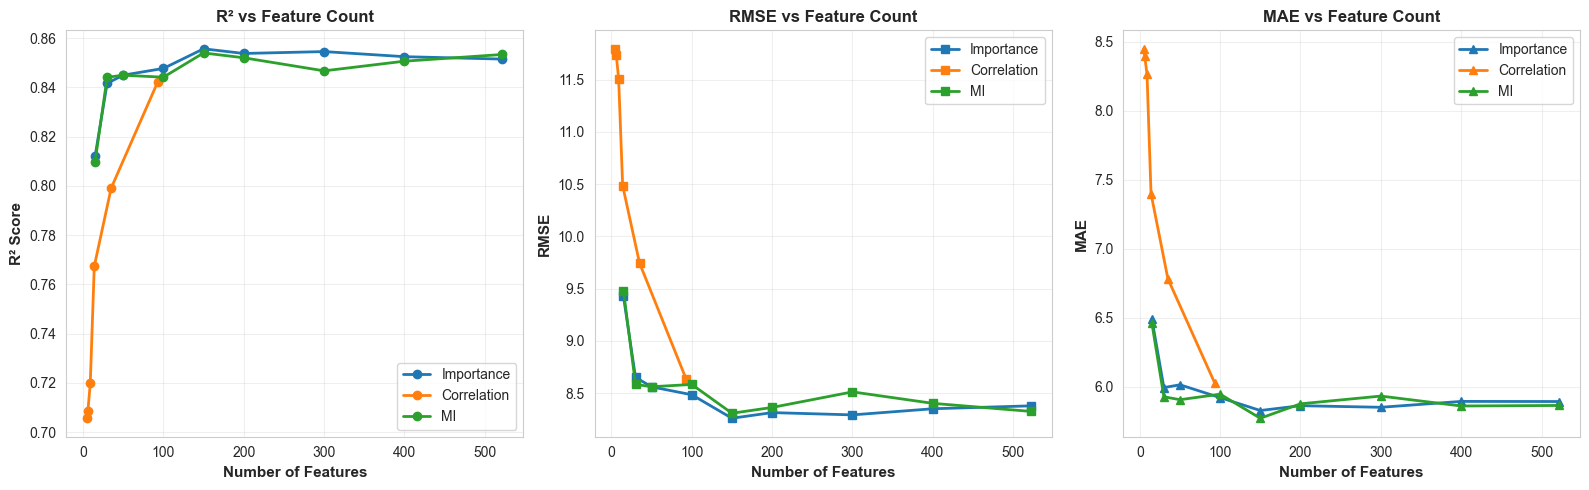

✓ Saved: 01_feature_optimization_comparison.png


In [9]:
# CELL 9: VISUALIZATION - Feature Optimization
print("\nCreating comparison visualization...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R²
for strategy in all_results['Strategy'].unique():
    strategy_data = all_results[all_results['Strategy'] == strategy].sort_values('N_Features')
    axes[0].plot(strategy_data['N_Features'], strategy_data['R²'], 
                marker='o', label=strategy, linewidth=2)

axes[0].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_title('R² vs Feature Count', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE
for strategy in all_results['Strategy'].unique():
    strategy_data = all_results[all_results['Strategy'] == strategy].sort_values('N_Features')
    axes[1].plot(strategy_data['N_Features'], strategy_data['RMSE'], 
                marker='s', label=strategy, linewidth=2)

axes[1].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[1].set_ylabel('RMSE', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE vs Feature Count', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAE
for strategy in all_results['Strategy'].unique():
    strategy_data = all_results[all_results['Strategy'] == strategy].sort_values('N_Features')
    axes[2].plot(strategy_data['N_Features'], strategy_data['MAE'], 
                marker='^', label=strategy, linewidth=2)

axes[2].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[2].set_ylabel('MAE', fontsize=11, fontweight='bold')
axes[2].set_title('MAE vs Feature Count', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/01_feature_optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 01_feature_optimization_comparison.png")

In [10]:
# CELL 10: TRAIN FINAL MODEL
print("\n" + "="*80)
print("STEP 4: TRAINING FINAL XGBOOST MODEL")
print("="*80)

final_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

print("\nTraining on full preprocessed dataset...")
final_model.fit(X_train, y_train)

# Evaluate
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)

print(f"\nFinal Model Performance:")
print(f"  Training R²: {train_r2:.4f}")
print(f"  Testing R²:  {test_r2:.4f}")
print(f"  Testing RMSE: {test_rmse:.4f}")
print(f"  Testing MAE:  {test_mae:.4f}")

print(f"\n✓ Model trained")


STEP 4: TRAINING FINAL XGBOOST MODEL

Training on full preprocessed dataset...

Final Model Performance:
  Training R²: 0.9664
  Testing R²:  0.8579
  Testing RMSE: 8.1939
  Testing MAE:  5.7875

✓ Model trained


In [11]:
# CELL 11: COMPUTE SHAP VALUES
print("\n" + "="*80)
print("STEP 5: SHAP EXPLAINABLE AI ANALYSIS")
print("="*80)

print("\nComputing SHAP values (this may take 5-10 minutes)...")

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed for {len(X_test)} test samples")


STEP 5: SHAP EXPLAINABLE AI ANALYSIS

Computing SHAP values (this may take 5-10 minutes)...
✓ SHAP values computed for 913 test samples


In [12]:
# CELL 12: Extract SHAP information for dashboard
import pandas as pd
import numpy as np

print("="*80)
print("SHAP FEATURE IMPORTANCE RANKING")
print("="*80)

# Get feature names from X_test (the preprocessed data)
feature_names = X_test.columns.tolist()

# Calculate mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': shap_importance
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

shap_df['Rank'] = range(1, len(shap_df) + 1)

print("\nTop 30 Features by SHAP:")
print(shap_df.head(30).to_string())

print("\n" + "="*80)
print("KEY FEATURE STATISTICS & SHAP RELATIONSHIP")
print("="*80)

key_features = ['numFeaturedPhotos_pct', 'lengthMiles', 'avgRating', 'elevationGainMeters', 
                'numPhotos', 'numRecordings', 'numRecordings_pct', 'numReviews', 'collections_trending']

for feature in key_features:
    if feature in X_test.columns:
        feature_idx = feature_names.index(feature)
        data = X_test[feature]
        shap_vals = shap_values[:, feature_idx]
        
        print(f"\n{feature}:")
        print(f"  Range: {data.min():.4f} to {data.max():.4f}")
        print(f"  Mean: {data.mean():.4f}, Median: {data.median():.4f}")
        print(f"  SHAP Mean Absolute: {np.abs(shap_vals).mean():.6f}")
        print(f"  SHAP Range: {shap_vals.min():.6f} to {shap_vals.max():.6f}")
        
        # Correlation between feature value and SHAP value
        corr = np.corrcoef(data, shap_vals)[0, 1]
        print(f"  Correlation (Feature vs SHAP): {corr:.4f}")
        
        # Show what happens at different levels
        percentiles = [0, 25, 50, 75, 100]
        print(f"  SHAP by percentile:")
        for pct in percentiles:
            val = np.percentile(data, pct)
            # Find SHAP values for samples near this percentile
            mask = (data >= np.percentile(data, max(0, pct-5))) & (data <= np.percentile(data, min(100, pct+5)))
            avg_shap = shap_vals[mask].mean() if mask.sum() > 0 else np.nan
            print(f"    {pct:3d}%ile (value={val:8.2f}): avg SHAP={avg_shap:8.4f}")

print("\n" + "="*80)
print("EXTRACTION COMPLETE - COPY THIS OUTPUT TO CLAUDE")
print("="*80)

SHAP FEATURE IMPORTANCE RANKING

Top 30 Features by SHAP:
                            Feature  Mean_SHAP  Rank
0             numFeaturedPhotos_pct   5.458975     1
1                         avgRating   3.792099     2
2                          isClosed   3.482054     3
3       collections_with_photos_pct   2.507925     4
4              collections_trending   2.145404     5
5                           numPOIs   2.111718     6
6                 numRecordings_pct   1.528631     7
7                sentence_count_all   1.108852     8
8          dist_to_nearest_metro_km   0.983559     9
9                   sentiment_views   0.726701    10
10                    numPhotos_pct   0.635501    11
11                     lengthMeters   0.622877    12
12              elevationGainMeters   0.603454    13
13                    estimatedTime   0.498731    14
14                        hasAlerts   0.485920    15
15                    sentiment_all   0.485736    16
16          collections_hidden-gems   0.4


Creating SHAP visualizations...
  1/4: SHAP Summary Bar Plot


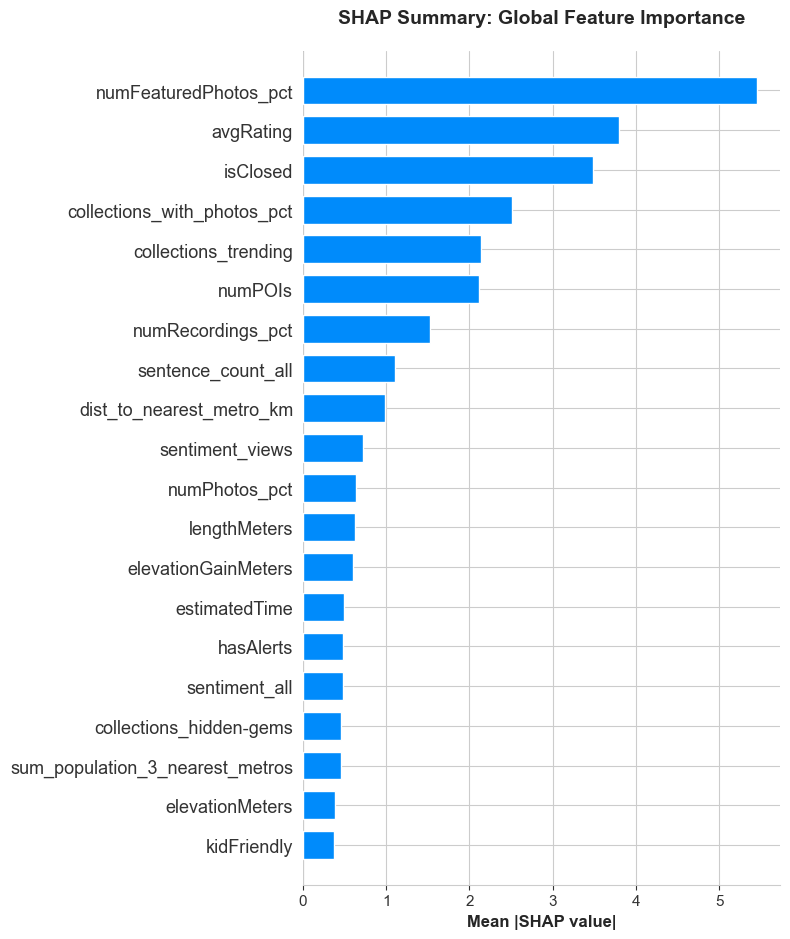

    ✓ Saved: 02_shap_summary_bar.png


In [13]:
# CELL 12: SHAP SUMMARY BAR PLOT
print("\nCreating SHAP visualizations...")
print("  1/4: SHAP Summary Bar Plot")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Summary: Global Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/02_shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("    ✓ Saved: 02_shap_summary_bar.png")

  2/4: SHAP Beeswarm Plot


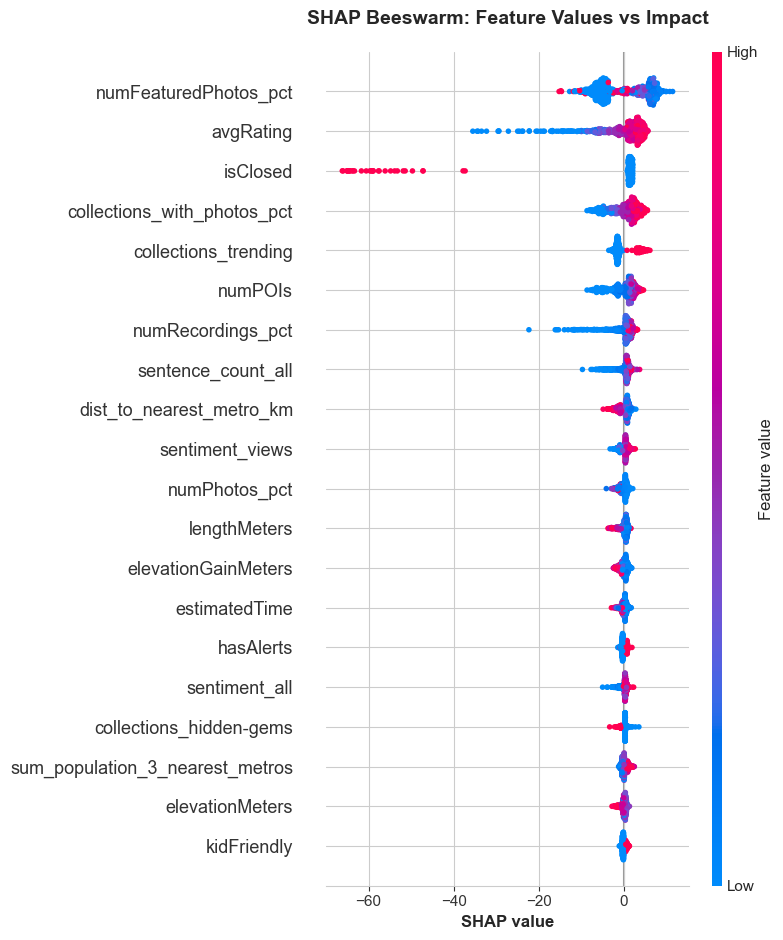

    ✓ Saved: 03_shap_beeswarm.png


In [14]:
# CELL 13: SHAP BEESWARM PLOT
print("  2/4: SHAP Beeswarm Plot")

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm: Feature Values vs Impact', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP value', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/03_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("    ✓ Saved: 03_shap_beeswarm.png")

  3/4: SHAP Dependence Plots (Top 4 Features)


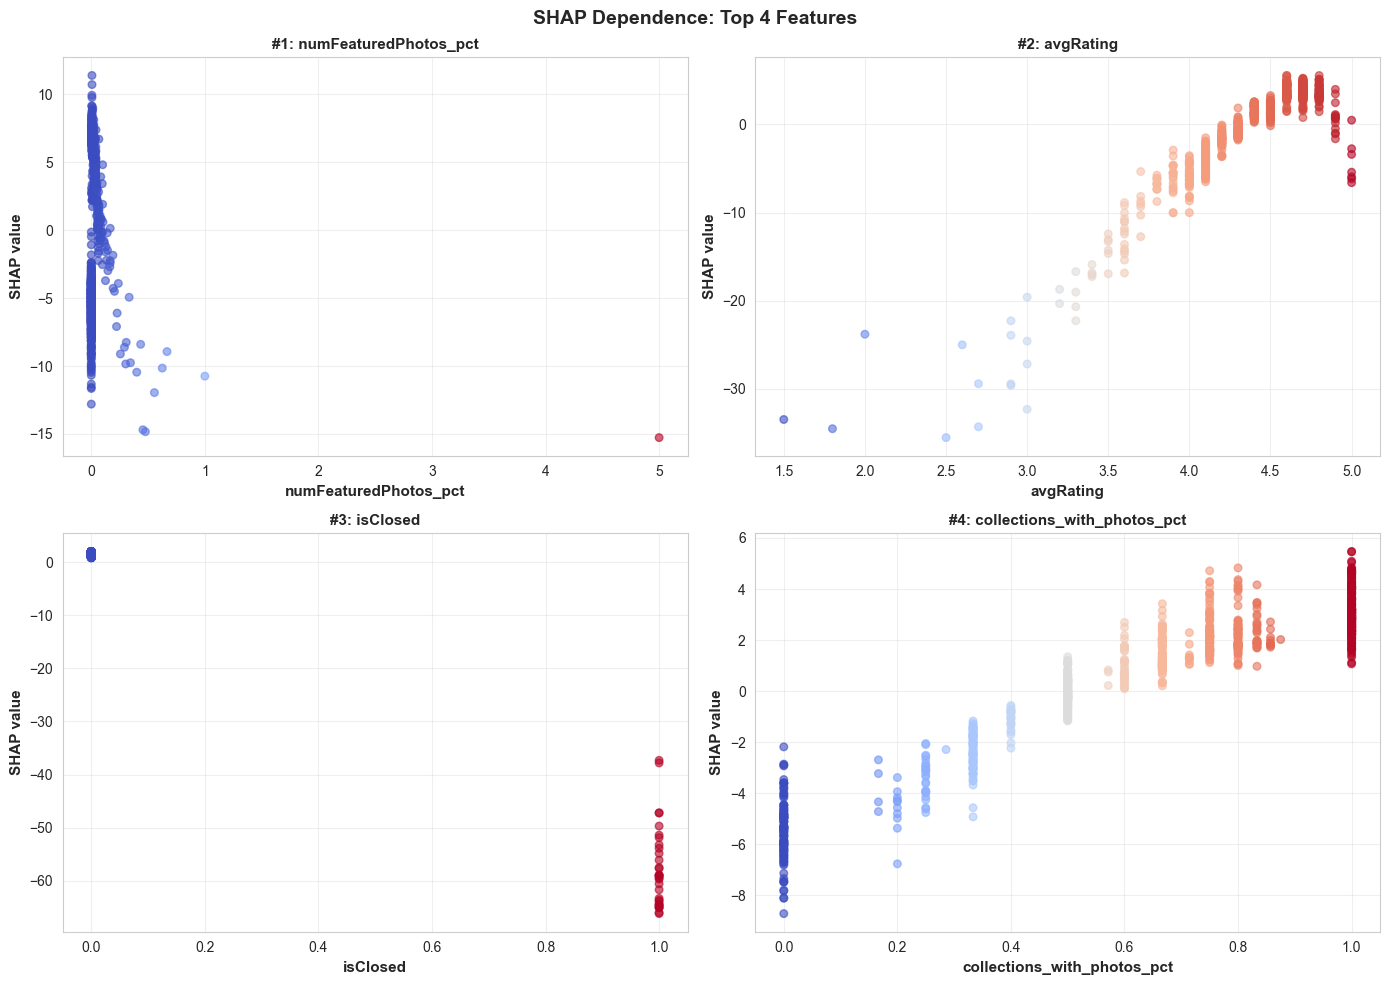

    ✓ Saved: 04_shap_dependence_plots.png


In [15]:
# CELL 14: SHAP DEPENDENCE PLOTS
print("  3/4: SHAP Dependence Plots (Top 4 Features)")

# Top 4 features
shap_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(shap_importance)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature_idx in enumerate(top_features_idx):
    ax = axes[idx]
    feature_name = X_test.columns[feature_idx]
    
    scatter = ax.scatter(
        X_test.iloc[:, feature_idx],
        shap_values[:, feature_idx],
        c=X_test.iloc[:, feature_idx],
        cmap='coolwarm',
        alpha=0.6,
        s=30
    )
    
    ax.set_xlabel(feature_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('SHAP value', fontsize=11, fontweight='bold')
    ax.set_title(f'#{idx+1}: {feature_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('SHAP Dependence: Top 4 Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/04_shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("    ✓ Saved: 04_shap_dependence_plots.png")

  4/4: SHAP Force Plots (5 Predictions)


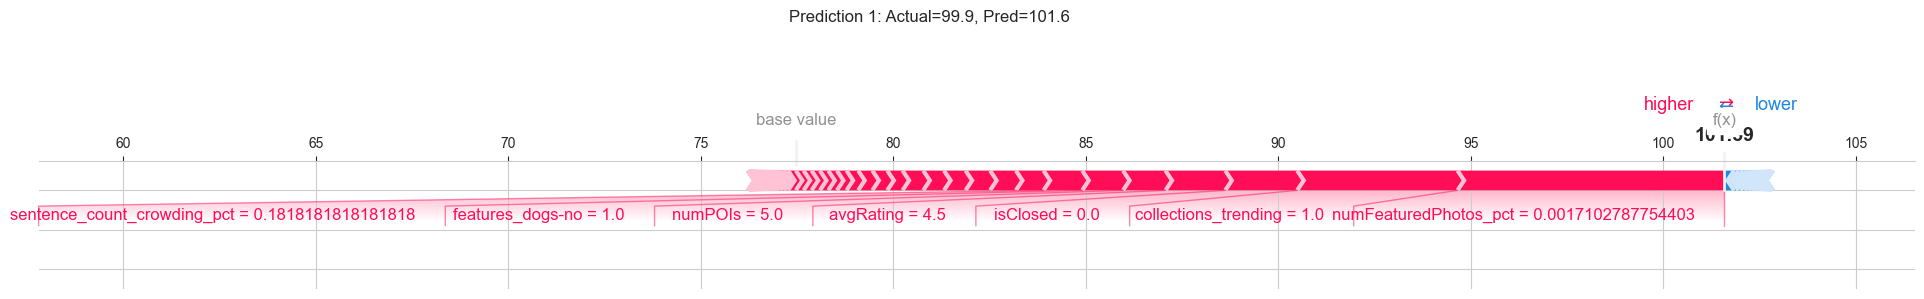

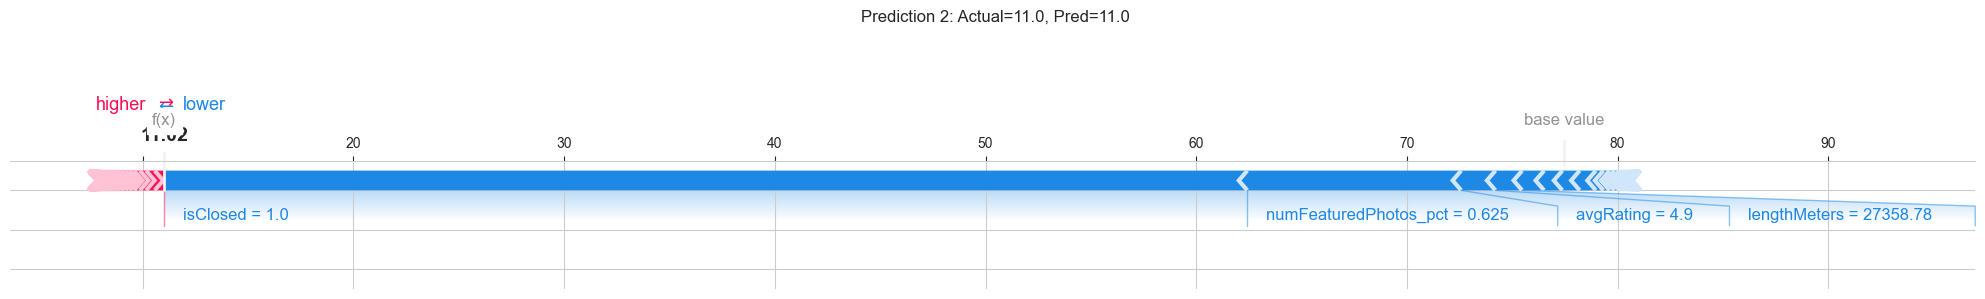

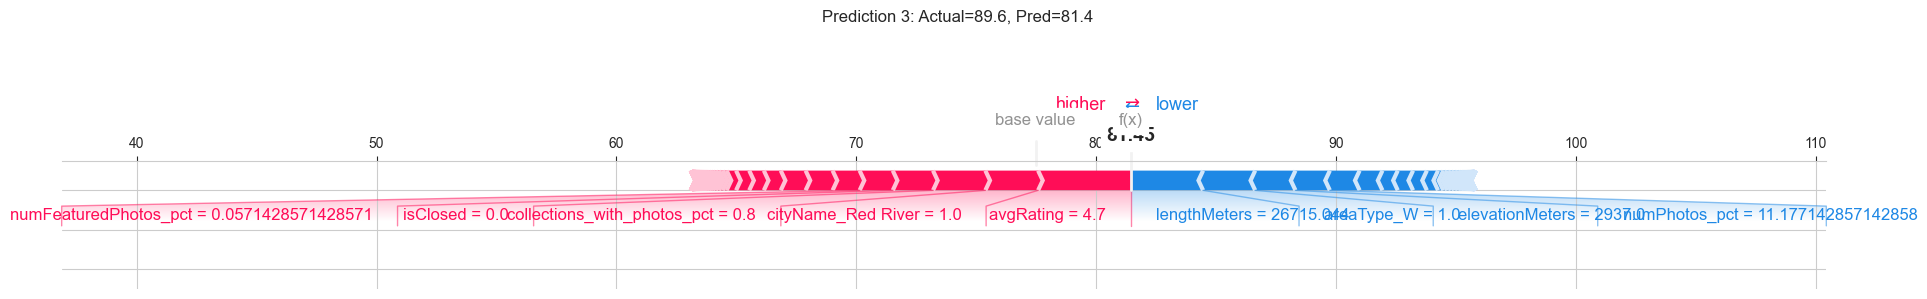

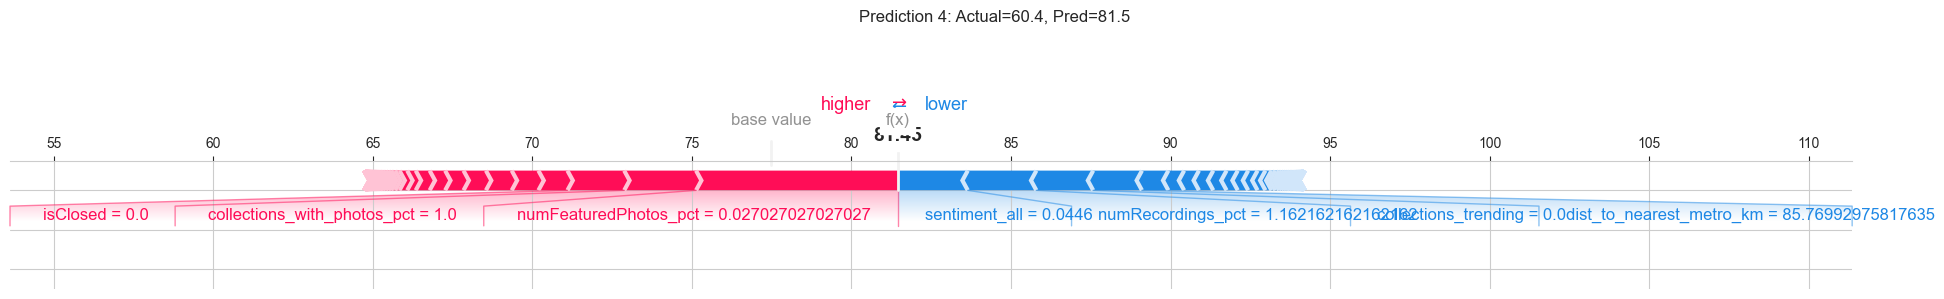

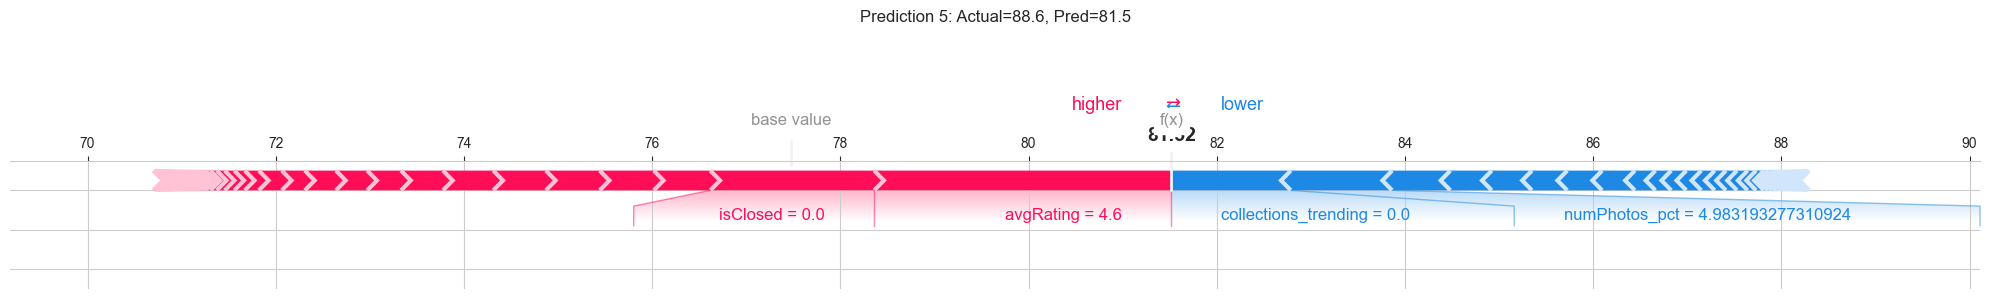

    ✓ Saved 5 force plots


In [16]:
# CELL 15: SHAP FORCE PLOTS
print("  4/4: SHAP Force Plots (5 Predictions)")

pred = final_model.predict(X_test)

# Select diverse samples
sample_indices = [
    np.argmax(pred),  # Highest
    np.argmin(pred),  # Lowest
    np.argsort(np.abs(pred - np.median(pred)))[0],  # Near median
    np.argsort(np.abs(pred - np.median(pred)))[1],
    np.argsort(np.abs(pred - np.median(pred)))[2]
]

for sample_num, actual_idx in enumerate(sample_indices):
    actual_pop = y_test.iloc[actual_idx]
    pred_pop = pred[actual_idx]
    
    shap.force_plot(
        explainer.expected_value,
        shap_values[actual_idx],
        X_test.iloc[actual_idx],
        matplotlib=True,
        show=False
    )
    
    plt.suptitle(f'Prediction {sample_num + 1}: Actual={actual_pop:.1f}, Pred={pred_pop:.1f}')
    plt.tight_layout()
    plt.savefig(f'./outputs/05_force_plot_{sample_num + 1}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"    ✓ Saved 5 force plots")

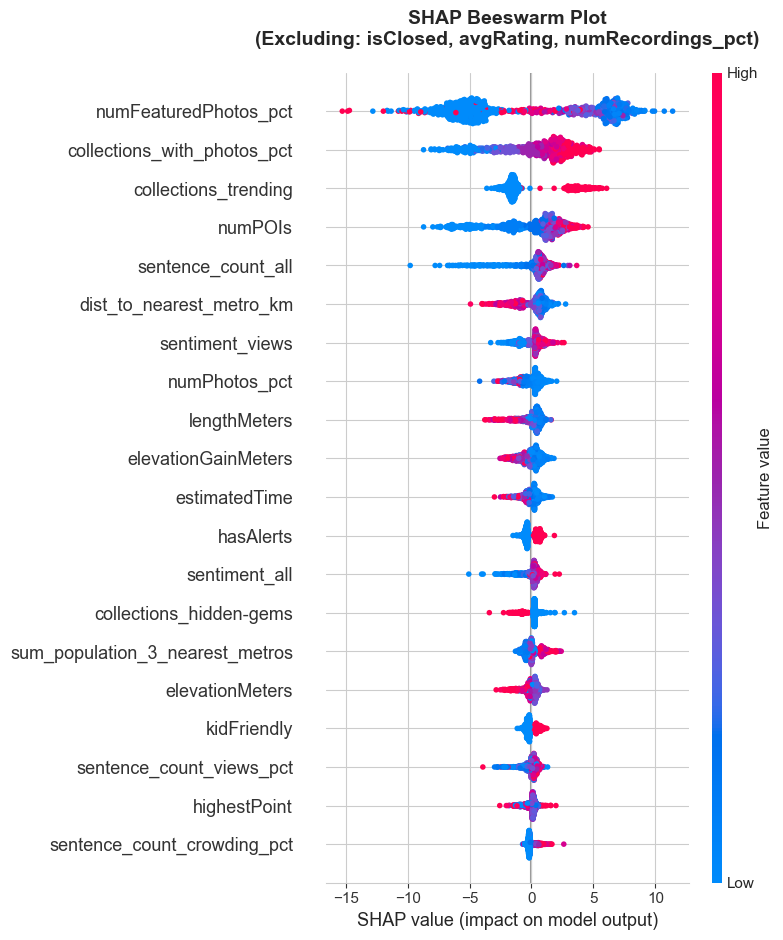

In [17]:
# Define features to exclude
features_to_exclude = ['isClosed', 'avgRating', 'numRecordings_pct']

# Get indices of features to KEEP
keep_indices = [i for i, feat in enumerate(X_test.columns) 
                if feat not in features_to_exclude]

# Filter SHAP values and features
shap_values_filtered = shap_values[:, keep_indices]
X_test_filtered = X_test.iloc[:, keep_indices]

# Create beeswarm plot
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_filtered, X_test_filtered, show=False)
plt.title('SHAP Beeswarm Plot\n(Excluding: isClosed, avgRating, numRecordings_pct)', 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./outputs/shap_beeswarm_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# CELL 16: DECISION RULES & SUMMARY
print("\n" + "="*80)
print("EXTRACTING DECISION RULES & GENERATING REPORTS")
print("="*80)

# Feature importance
mean_shap = np.abs(shap_values).mean(axis=0)
feature_impact = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': mean_shap,
    'Rank': range(1, len(mean_shap) + 1)
}).sort_values('Mean_SHAP', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_impact.head(10)[['Rank', 'Feature', 'Mean_SHAP']].to_string(index=False))

# Save decision rules
with open('./outputs/decision_rules.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("SHAP-BASED DECISION RULES\n")
    f.write("="*80 + "\n\n")

    f.write(f"Model Performance:\n")
    f.write(f"  Training R²: {train_r2:.4f}\n")
    f.write(f"  Testing R²:  {test_r2:.4f}\n")
    f.write(f"  Testing RMSE: {test_rmse:.4f}\n")
    f.write(f"  Testing MAE:  {test_mae:.4f}\n\n")
    
    f.write(f"Top 10 Features:\n")
    for idx, row in feature_impact.head(10).iterrows():
        f.write(f"{int(row['Rank']):2d}. {row['Feature']:<40} ({row['Mean_SHAP']:.6f})\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("RECOMMENDATIONS:\n")
    f.write("="*80 + "\n\n")
    f.write("To increase trail popularity, focus on:\n")
    f.write("1. Featured photos on AllTrails\n")
    f.write("2. Keeping trail open and well-maintained\n")
    f.write("3. Encouraging visitor ratings and reviews\n")
    f.write("4. Updating trail amenities and information\n\n")
    f.write("See visualizations (02-05) for detailed feature analysis.\n")

print("\n✓ Saved: decision_rules.txt")

# Summary
with open('./outputs/SHAP_ANALYSIS_SUMMARY.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("SHAP EXPLAINABLE AI ANALYSIS SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write("VISUALIZATIONS CREATED:\n")
    f.write("  - 01_feature_optimization_comparison.png: 3-strategy comparison\n")
    f.write("  - 02_shap_summary_bar.png: Global feature importance\n")
    f.write("  - 03_shap_beeswarm.png: Feature distributions\n")
    f.write("  - 04_shap_dependence_plots.png: Top 4 features\n")
    f.write("  - 05_force_plot_*.png: 5 individual predictions\n\n")
    f.write(f"MODEL PERFORMANCE:\n")
    f.write(f"  Training R²: {train_r2:.4f}\n")
    f.write(f"  Testing R²:  {test_r2:.4f}\n\n")
    f.write("See decision_rules.txt for actionable insights.\n")

print("✓ Saved: SHAP_ANALYSIS_SUMMARY.txt")

print("\n" + "="*80)
print("✓ COMPLETE ANALYSIS FINISHED!")
print("="*80)
print("\nGenerated Files:")
print("  - feature_optimization_results.csv")
print("  - 01_feature_optimization_comparison.png")
print("  - 02_shap_summary_bar.png")
print("  - 03_shap_beeswarm.png")
print("  - 04_shap_dependence_plots.png")
print("  - 05_force_plot_1-5.png")
print("  - decision_rules.txt")
print("  - SHAP_ANALYSIS_SUMMARY.txt")


EXTRACTING DECISION RULES & GENERATING REPORTS

Top 10 Most Important Features:
 Rank                     Feature  Mean_SHAP
   29       numFeaturedPhotos_pct   5.458975
    8                   avgRating   3.792099
   17                    isClosed   3.482054
   31 collections_with_photos_pct   2.507925
   81        collections_trending   2.145404
   21                     numPOIs   2.111718
   28           numRecordings_pct   1.528631
    2          sentence_count_all   1.108852
  523    dist_to_nearest_metro_km   0.983559
    3             sentiment_views   0.726701

✓ Saved: decision_rules.txt
✓ Saved: SHAP_ANALYSIS_SUMMARY.txt

✓ COMPLETE ANALYSIS FINISHED!

Generated Files:
  - feature_optimization_results.csv
  - 01_feature_optimization_comparison.png
  - 02_shap_summary_bar.png
  - 03_shap_beeswarm.png
  - 04_shap_dependence_plots.png
  - 05_force_plot_1-5.png
  - decision_rules.txt
  - SHAP_ANALYSIS_SUMMARY.txt


In [19]:
# Extract Force Plot Sample Values for Testing

print("="*80)
print("EXTRACTING FORCE PLOT SAMPLE VALUES")
print("="*80)

# Use variables that already exist from your notebook
pred = final_model.predict(X_test)

# Get same sample indices as force plots
sample_indices = [
    np.argmax(pred),  # Highest
    np.argmin(pred),  # Lowest
    np.argsort(np.abs(pred - np.median(pred)))[0],  # Near median 1
    np.argsort(np.abs(pred - np.median(pred)))[1],  # Near median 2
    np.argsort(np.abs(pred - np.median(pred)))[2]   # Near median 3
]

print("\nForce Plot Samples from your trained model:\n")

for sample_num, actual_idx in enumerate(sample_indices, 1):
    actual_pop = y_test.iloc[actual_idx]
    pred_pop = pred[actual_idx]
    sample_data = X_test.iloc[actual_idx]
    
    print(f"\n{'='*80}")
    print(f"FORCE PLOT {sample_num}")
    print(f"{'='*80}")
    print(f"Actual Popularity: {actual_pop:.4f}")
    print(f"Predicted Popularity: {pred_pop:.4f}")
    print(f"\nAll {len(X_test.columns)} Features:")
    print("-"*80)
    
    for i, (feat_name, feat_val) in enumerate(sample_data.items(), 1):
        print(f"{i:3d}. {feat_name:<50} = {feat_val}")
    
    # Save to CSV
    feature_dict = dict(sample_data)
    feature_dict['actual_popularity'] = actual_pop
    feature_dict['predicted_popularity'] = pred_pop
    
    df_sample = pd.DataFrame([feature_dict])
    csv_filename = f'force_plot_{sample_num}_features.csv'
    df_sample.to_csv(csv_filename, index=False)
    print(f"\n✓ Saved to: {csv_filename}")

EXTRACTING FORCE PLOT SAMPLE VALUES

Force Plot Samples from your trained model:


FORCE PLOT 1
Actual Popularity: 99.9305
Predicted Popularity: 101.5926

All 525 Features:
--------------------------------------------------------------------------------
  1. sentiment_all                                      = 0.205
  2. sentence_count_all                                 = 22
  3. sentiment_views                                    = 0.4986
  4. sentiment_difficulty                               = -0.0356
  5. sentiment_crowding                                 = 0.0113
  6. sentiment_conditions                               = -0.254
  7. adaAccessible                                      = 0
  8. avgRating                                          = 4.5
  9. campingAvailable                                   = 0
 10. difficultyRating                                   = 3
 11. dogFriendly                                        = 0
 12. elevationGainMeters                                = 